# Handling Outliers

### Inter Quartile Range (IQR)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.impute import SimpleImputer as si

In [2]:
df_out = pd.read_csv('scholarship.csv')

In [3]:
df_out.head()

,semester_percentage,scholarship_exam_marks,got_scholarship
0,71.9,26,1
1,74.6,38,1
2,75.4,40,1
3,64.2,8,1
4,72.3,17,0


C:\Users\MISHAL MITTAL\AppData\Local\Temp\ipykernel_29876\3335443102.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_out['scholarship_exam_marks'])


<Axes: xlabel='scholarship_exam_marks', ylabel='Density'>

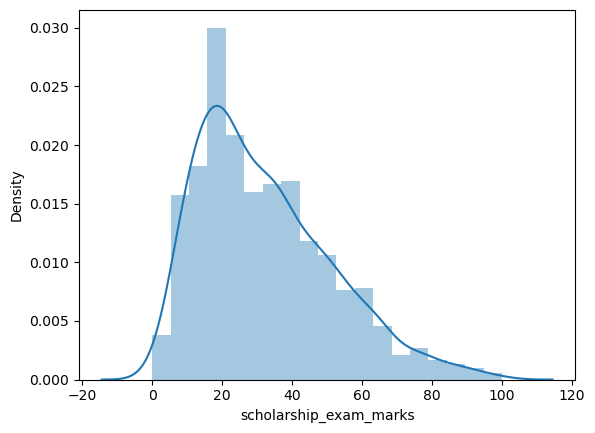

In [4]:
sns.distplot(df_out['scholarship_exam_marks'])

<Axes: ylabel='scholarship_exam_marks'>

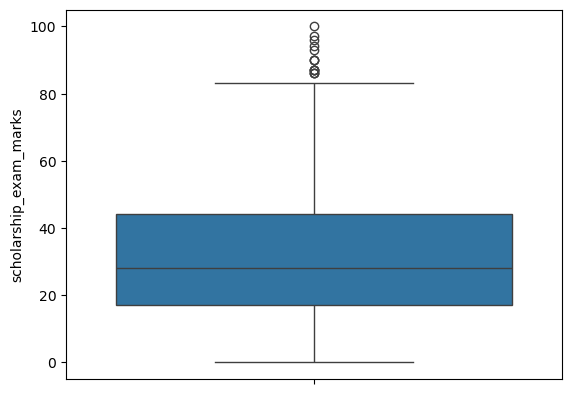

In [5]:
sns.boxplot(df_out['scholarship_exam_marks'])

In [7]:
Q1 = df_out['scholarship_exam_marks'].quantile(0.25)
Q3 = df_out['scholarship_exam_marks'].quantile(0.75)
IQR = Q3 - Q1
print(Q1, ',' , Q3, ',', IQR)

17.0 , 44.0 , 27.0


In [12]:
min_limit = Q1 - 1.5 * IQR
max_limit = Q3 + 1.5 * IQR 

print( max_limit , ',', min_limit)

81.0 , -23.5


### Trimming

In [18]:
df_out1 = df_out.copy()

In [19]:
df_out1.shape

(1000, 3)

In [20]:
df_out1[(df_out1['scholarship_exam_marks'] > max_limit) | (df_out1['scholarship_exam_marks'] < min_limit)]

,semester_percentage,scholarship_exam_marks,got_scholarship
9,77.5,94,1
40,66.0,86,1
61,75.1,86,0
134,63.3,93,0
162,78.0,90,0
283,70.9,87,0
290,83.8,87,0
311,69.7,87,1
324,66.4,90,0
403,67.1,83,0


In [21]:
df_out1 = df_out1[(df_out1['scholarship_exam_marks'] <= max_limit) & (df_out1['scholarship_exam_marks'] >= min_limit)]

In [22]:
df_out1.shape

(984, 3)

<Axes: ylabel='scholarship_exam_marks'>

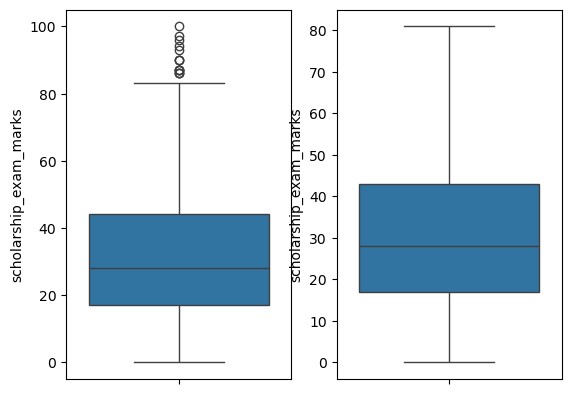

In [33]:
plt.subplot(1,2,1)
sns.boxplot(df_out['scholarship_exam_marks'])

plt.subplot(1,2,2)
sns.boxplot(df_out1['scholarship_exam_marks'])

### Capping

In [23]:
df_out2 = df_out.copy()

In [25]:
df_out2.shape

(1000, 3)

In [26]:
df_out2['scholarship_exam_marks'] = np.where((df_out2['scholarship_exam_marks'] > max_limit), max_limit ,
                                             (np.where((df_out2['scholarship_exam_marks'] < min_limit), min_limit, df_out2['scholarship_exam_marks'])))

In [27]:
df_out2.shape

(1000, 3)

<Axes: ylabel='scholarship_exam_marks'>

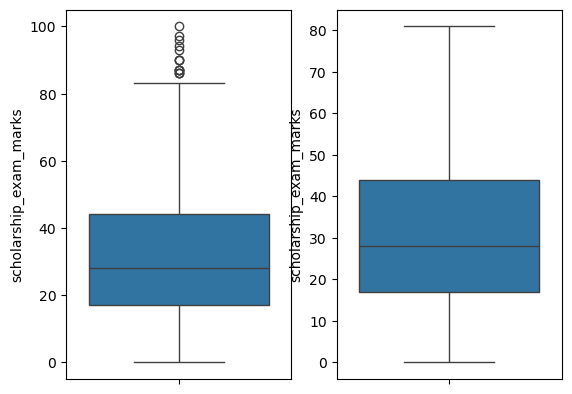

In [32]:
plt.subplot(1,2,1)
sns.boxplot(df_out['scholarship_exam_marks'])

plt.subplot(1,2,2)
sns.boxplot(df_out2['scholarship_exam_marks'])